In [2]:
import math 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

In [3]:
def f(x):
    return 3 * x ** 2 - 4 * x + 5 

In [4]:
f(3.0)

20.0

In [5]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
print(ys)

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]
[100.      91.6875  83.75    76.1875  69.      62.1875  55.75    49.6875
  44.      38.6875  33.75    29.1875  25.      21.1875  17.75    14.6875
  12.       9.6875   7.75     6.1875   5.       4.1875   3.75     3.6875
   4.       4.6875   5.75     7.1875   9.      11.1875  13.75    16.6875
  20.      23.6875  27.75    32.1875  37.      42.1875  47.75    53.6875]


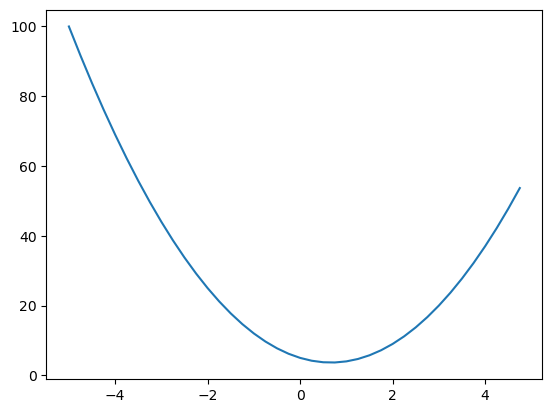

In [6]:
plt.plot(xs, ys)

In [7]:
# derivative
h = 0.00000001 
x = 2/3
(f(x + h) - f(x)) / h

0.0

In [8]:
# more complexity?

a = 2.0 
b = -3.0 
c = 10.0 
d1 = (a * b) + c

a += h
# b += h 
# c += h

d2 = (a * b) + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)



d1 4.0
d2 3.99999997
slope -2.999999981767587


In [100]:
class Value: 
    
    def __init__(self, data, _children=(), _op='', label=''): 
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self._backward = lambda: None
    def __repr__(self): 
        return f"Value(data={self.data}, grad={self.grad})"
    
    def __add__(self, other): 
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out 
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out 
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out
    
    def tanh(self): 
        x = self.data 
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - out.data**2) * out.grad
        out._backward = _backward
        return out    
    
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for v in reversed(topo):
            v._backward()


a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L' 

In [36]:
# !pip install graphviz
from graphviz import Digraph

In [87]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        dot.node(name=uid, label = "{ %s | %.3f | gd %.3f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

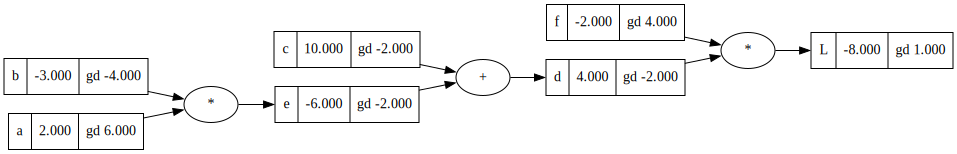

In [88]:
nodes, _ = trace(L)
for node in nodes:
    node.grad = 0.0
L.label = 'L'
L.backward()
draw_dot(L)

In [ ]:
L = d * f 

In [71]:
a.data += 0.01 * a.grad 
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad 
f.data += 0.01 * f.grad  

e = a * b 
d = e + c 
L = d * f 

print(L.data)

-7.286496


In [70]:
def lol(): 
    
    h = 0.00000001 
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L' 
    L1 = L.data
    
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0 + h, label = 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L' 
    L2 = L.data
    
    print((L2 - L1) / h) 
    
lol()

-2.000000165480742


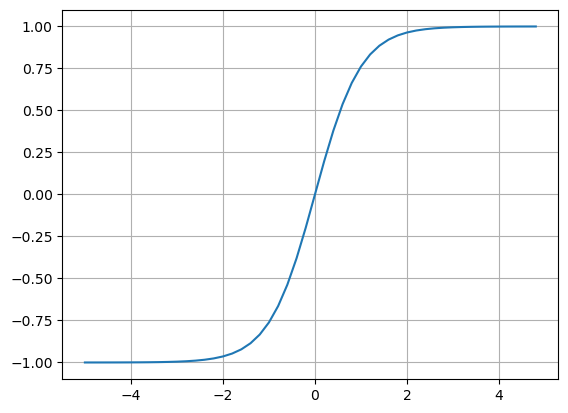

In [73]:
plt.plot((np.arange(-5, 5, 0.2)), np.tanh(np.arange(-5, 5, 0.2)));
plt.grid()

In [98]:
# input x1, x2 
x1 = Value(2.0, label = 'x1')
x2 = Value(1.5, label = 'x2')
# weights w1, w2 
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
# bias of the neuron 
# x1w1 + x2w2 + b 
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

b = Value(6.5, label = 'b')

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'



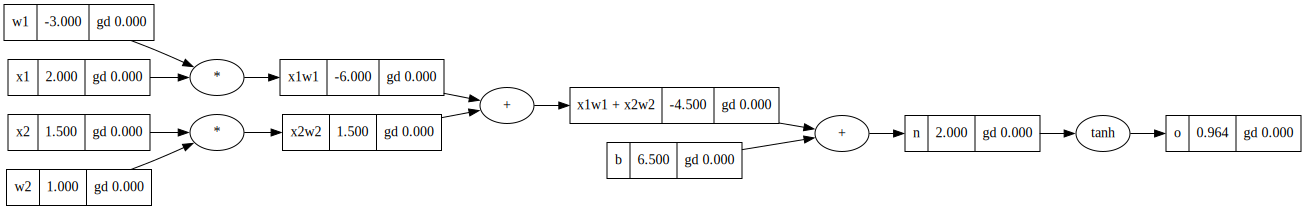

In [97]:
draw_dot(o)

In [99]:
nodes, _ = trace(o)
for node in nodes:
    node.grad = 0.0
o.backward()
print('o', o.data)
print('n', n.grad)
print('x1', x1.grad)
print('x2', x2.grad)
print('w1', w1.grad)
print('w2', w2.grad)
print('b', b.grad)

o 0.9640275800758169
n 0.0
x1 0.0
x2 0.0
w1 0.0
w2 0.0
b 0.0


In [ ]:
o.data 